# Notebook 2B — Tuning a Random Forest

*Day 4 · Student B's deep tuning lab — read the docstring, sweep, search, log, save.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome to your tuning lab — the random forest

Yesterday the whole team built the *same* pipeline and measured the *same* linear baseline. Today
you each take **one** model and tune it deeply. You own the **random forest (RF)**.

A random forest is an **ensemble** — it grows hundreds of **decision trees**, each on a random slice
of the data and a random subset of the features, then **averages** their predictions. One tree is
twitchy and overfits; the average of many de-correlated trees is accurate and steady. That averaging
is the whole trick.

This is a **lab, not a demo.** You'll:

1. **Read the docstring** and meet the knobs that actually matter.
2. **Sweep the main knobs by hand** and *plot* the bias–variance curve — watch over/underfitting appear.
3. Try the **categorical** knobs in a small table.
4. Run a **`GridSearchCV`** (small, exhaustive) and then a **`RandomizedSearchCV`** (for a bigger space).
5. **Log every run** with `log_experiment(...)`, then **save your best model** with `save_model(...)`.
6. Score your tuned model once on the **untouched test set**, map *where* it fails, and crack it open
   with **SHAP**.

> The grey **Setup** cell below has all the helpers. **Run it, don't read it.** Everything runs
> top-to-bottom as shipped — the "your turn" cells already work; your job is to *widen* the searches,
> change a knob, and look again. At the end you save `outputs/rf_preds.npz`, `models/rf.joblib`, and
> `outputs/rf_experiments.csv` — Notebooks 3 and 4 pick these up.


In [2]:
# The tools this notebook uses (the Setup cell above already loaded the data/plot helpers).
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import randint     # for RandomizedSearchCV: a discrete random distribution

print("Imports ready.")

Imports ready.


## 0 · Setup and recap — load, split, and the bar to beat

Same first moves as the common notebook, so this lab stands on its own. We **load → normalize by the
G-band → split** with the fixed seed (so you get the exact same stars as your teammates), and pull out
`[Fe/H]` as the target.

We predict **`[Fe/H]`** (metallicity), the hardest of the three stellar labels to read off a
low-resolution spectrum. `Teff` and `log g` come back later as the **axes we slice the errors over** —
the map of *where* the model is reliable.


In [3]:
# Load -> normalize-by-G -> split (identical recipe and seed as every notebook).
X, y, meta = load_data()
print("X:", X.shape, "| labels:", list(y.columns))

Xn = normalize_by_g(X, meta["gflux"])           # physics step: divide out brightness, keep spectral SHAPE
sp = train_cal_test_split(Xn, y, seed=0)         # fixed seed -> the SAME stars for the whole team
print("train / cal / test sizes:",
      sp["X_train"].shape[0], sp["X_cal"].shape[0], sp["X_test"].shape[0])

target = "FeH"                                    # our prediction target is metallicity
y_train = sp["y_train"][target].to_numpy()
y_cal   = sp["y_cal"][target].to_numpy()
y_test  = sp["y_test"][target].to_numpy()

# a small slice for FAST tuning — search here, fit the final model on the full split
_ti = np.random.default_rng(0).choice(sp["X_train"].shape[0], size=min(5000, sp["X_train"].shape[0]), replace=False)
X_tune, y_tune = sp["X_train"][_ti], sp["y_train"]["FeH"].to_numpy()[_ti]
print(f"tuning slice: {X_tune.shape[0]} stars (searches run here; final fit uses all {sp['X_train'].shape[0]})")

# Your model string (fixed for this lab — you own the random forest).
MODEL = "rf"
print(f"MODEL = {MODEL!r}")

Loaded xp_apogee_real.npz: REAL (Gaia XP x APOGEE)  —  30,000 stars (subsampled from 263,722; pass n=None for all), 110 coefficients.
X: (30000, 110) | labels: ['Teff', 'logg', 'FeH', 'alpha', 'dist']
train / cal / test sizes: 18000 6000 6000
tuning slice: 5000 stars (searches run here; final fit uses all 18000)
MODEL = 'rf'


In [4]:
# The bar to beat: the linear baseline from the common notebook. If you ran 02_pipeline_common,
# its predictions are saved in outputs/linear_preds.npz -- load them. If not, refit in 2 lines.
try:
    d_lin = load_outputs("linear_preds.npz")
    baseline_rmse = regression_metrics(d_lin["y_test_true"], d_lin["y_test_pred"])["RMSE"]
    print(f"loaded linear baseline from outputs/  ->  test RMSE = {baseline_rmse:.4f} dex")
except FileNotFoundError:
    lin = make_model("linear").fit(sp["X_train"], y_train)
    baseline_rmse = regression_metrics(y_test, lin.predict(sp["X_test"]))["RMSE"]
    print(f"(re-fit a quick linear baseline)  ->  test RMSE = {baseline_rmse:.4f} dex")

loaded linear baseline from outputs/  ->  test RMSE = 0.2232 dex


*Caption: the linear baseline lands around **0.22 dex** RMSE on `[Fe/H]`. That's the number every random-forest run below is trying to beat — and, more interestingly, **where** it beats it.*

> **A note on speed.** Every *exploratory* search below (the by-hand sweeps, `GridSearchCV`, and `RandomizedSearchCV`) runs on a small fixed **tuning slice** (`X_tune`, `y_tune` — about 5,000 training stars) so the lab stays fast and interactive. The relative ranking of hyper-parameters is the same on the slice as on the full set, so your tuning conclusions still hold. The **final tuned model in §5** and the **saved predictions in §7** are fit on the *full* training split — that's the canonical data Notebooks 3 and 4 expect.

## 1 · Meet your estimator — `RandomForestRegressor`

Before you tune anything, read what you're tuning. The single most useful habit in applied ML is to
**read the docstring** — every knob, its default, and what it does, straight from the source. Run the
next cell; skim the `Parameters` section (you don't need to read all of it).

In a Jupyter notebook you can also type `RandomForestRegressor?` in a cell to pop up the same help.


In [5]:
# Print the docstring. Skim the Parameters section -- that's the menu of knobs you can turn.
help(RandomForestRegressor)

Help on class RandomForestRegressor in module sklearn.ensemble._forest:

class RandomForestRegressor(ForestRegressor)
 |  RandomForestRegressor(
 |      n_estimators=100,
 |      *,
 |      criterion='squared_error',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features=1.0,
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest regressor.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  regressors on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"

### The knobs that matter (your tuning menu)

A forest has many parameters, but only a handful move the needle for us. Here's the field guide:

| Knob | Kind | What it does | Which way? |
|---|---|---|---|
| `n_estimators` | continuous/ordinal | number of trees | more = steadier & slower, **diminishing returns**; not a sweet-spot knob |
| `max_depth` | continuous/ordinal | how deep each tree may grow | `None` = grow until pure (most flexible); shallow = underfit |
| `min_samples_leaf` | continuous/ordinal | min stars per leaf | larger = smoother/**regularized**; `1` = most flexible |
| `max_features` | categorical | features tried per split | `1.0` (all), `"sqrt"`, `"log2"` — controls tree de-correlation |
| `criterion` | categorical | the split-quality rule | `squared_error`, `friedman_mse`, `absolute_error`, `poisson` |

Two ideas to hold onto:

- **`n_estimators` is a speed/quality dial, not a knob to *optimize*.** More trees only ever helps
  accuracy and stability — it never overfits — it just costs time. You pick the most you can afford.
- **`max_depth` and `min_samples_leaf` are the real regularizers.** Very deep trees with tiny leaves
  memorize the training data (each *single* tree overfits); the forest's averaging hides much of it,
  but not all. These knobs trade **bias** (too rigid) against **variance** (too twitchy).

Two free goodies a forest hands you, which we'll use:

- **`oob_score=True`** — *out-of-bag* validation. Each tree is trained on a bootstrap sample, leaving
  ~1/3 of the stars out; their predictions on those held-out stars give an honest validation score
  **for free**, no separate split needed.
- **`feature_importances_`** — after fitting, a 110-vector telling you how much each XP coefficient
  mattered. A natural "which coefficients carry `[Fe/H]`?" probe.

*References:*
[RandomForestRegressor API](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) ·
[Ensembles / forests (User Guide)](https://scikit-learn.org/stable/modules/ensemble.html#forest).


In [6]:
# Fit the forest ONCE with sensible defaults via the canonical factory, and record the run.
# make_model("rf") == Pipeline(StandardScaler + RandomForestRegressor(n_estimators=150,
#                              min_samples_leaf=3, random_state=0, n_jobs=-1)).
# (Trees are scale-invariant, so the StandardScaler is harmless here -- we keep it so the pipeline is
#  byte-identical to every other model in the project.)
rf_pipe = make_model("rf", oob_score=True)       # turn on out-of-bag scoring (free validation)
rf_pipe.fit(sp["X_train"], y_train)

rf = rf_pipe.named_steps["randomforestregressor"]    # reach inside the fitted pipeline
oob_r2 = rf.oob_score_                                 # out-of-bag R^2 (no extra fitting needed)
start = regression_metrics(y_test, rf_pipe.predict(sp["X_test"]))
print(f"default RF: test RMSE = {start['RMSE']:.4f} dex | test R2 = {start['R2']:.3f} | OOB R2 = {oob_r2:.3f}")

# Log this run so we have a durable record of "what did I try, and how did it score?"
log_experiment(MODEL,
               {"n_estimators": 150, "max_depth": None, "min_samples_leaf": 3,
                "max_features": 1.0, "criterion": "squared_error"},
               {"oob_r2": round(oob_r2, 4), "test_rmse": round(start["RMSE"], 4)})
print("logged the default run to outputs/rf_experiments.csv")

default RF: test RMSE = 0.1741 dex | test R2 = 0.744 | OOB R2 = 0.745
logged the default run to outputs/rf_experiments.csv


/tmp/claude-1000/ipykernel_826548/586013563.py:529: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)


*Caption: out of the box the forest already clears the linear baseline. Notice the **OOB R²** sits right next to the test R² — that's the free out-of-bag estimate doing the job of a validation set. From here, tuning is about squeezing out a little more and (mostly) understanding *where* it helps.*

## 2 · Sweep the continuous knobs by hand — and *plot* the curve

The most important tuning skill is **seeing** the bias–variance tradeoff, not just trusting a search.
So before any automated tool, we sweep a knob across a range *by hand*, record train vs validation
error at each setting, and **plot** it. The shape of that curve tells you which end is **underfitting**
(too rigid — high error on *both* train and validation) and which is **overfitting** (too flexible —
low train error but rising validation error).

We'll use the held-out **calibration** split as our validation set here (we keep the **test** split
sealed until the very end). The first sweep is the cleanest RF story: **`max_depth`**.


In [7]:
# <- your turn: sweep max_depth and watch train vs validation RMSE.
#    The shipped grid runs as-is; WIDEN it (add more depths) and look again.
depths = [3, 6, 10, 16, None]            # <- your turn: try e.g. [2, 4, 6, 8, 12, 20, None]

# Keep the forest LIGHT during the sweep (fewer trees) so it runs in well under a minute. n_estimators
# is just a speed dial here -- it doesn't change WHERE the bias-variance sweet spot is.
rows = []
for d in depths:
    pipe = make_model("rf", n_estimators=80, max_depth=d)
    pipe.fit(X_tune, y_tune)                                             # search on the fast tuning slice
    tr = regression_metrics(y_tune, pipe.predict(X_tune))["RMSE"]        # train RMSE (on the slice)
    va = regression_metrics(y_cal,   pipe.predict(sp["X_cal"]))["RMSE"]  # validation RMSE
    rows.append({"max_depth": d, "train_rmse": tr, "val_rmse": va})
    log_experiment(MODEL, {"n_estimators": 80, "max_depth": d}, {"val_rmse": round(va, 4)})
    print(f"max_depth={str(d):>4}  train={tr:.4f}  val={va:.4f}")

depth_df = pd.DataFrame(rows)

max_depth=   3  train=0.2495  val=0.2592


max_depth=   6  train=0.1843  val=0.2190


max_depth=  10  train=0.1204  val=0.2011


max_depth=  16  train=0.0905  val=0.1963


max_depth=None  train=0.0891  val=0.1960


/tmp/claude-1000/ipykernel_826548/586013563.py:529: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)


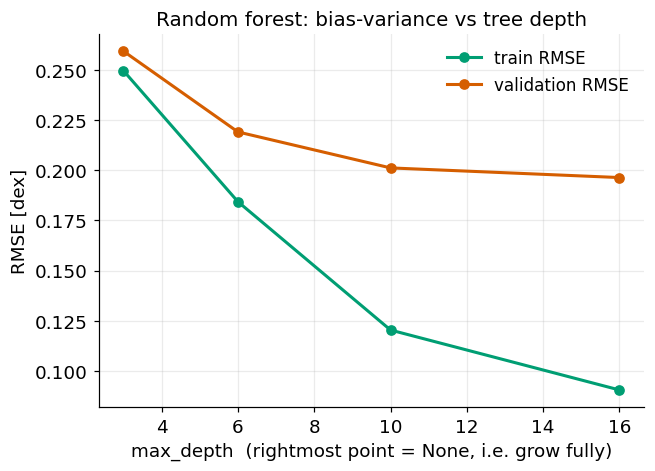

In [8]:
# Plot the bias-variance curve. We put depth on the x-axis; None ("grow fully") goes at the far right.
xs = [d if d is not None else max([z for z in depth_df["max_depth"] if z is not None]) + 8
      for d in depth_df["max_depth"]]
fig, ax = plt.subplots()
ax.plot(xs, depth_df["train_rmse"], "o-", color=COLORS["rf"],   label="train RMSE")
ax.plot(xs, depth_df["val_rmse"],   "o-", color=COLORS["nn"],   label="validation RMSE")
ax.set_xlabel("max_depth  (rightmost point = None, i.e. grow fully)")
ax.set_ylabel("RMSE [dex]")
ax.set_title("Random forest: bias-variance vs tree depth")
ax.legend()
savefig("nb2b_rf_depth_curve.png")
plt.show()

# <- your turn: which end is UNDERFITTING (shallow: high train AND val error)?
#    Where does validation stop improving? Past that, you're spending time for nothing.

*Caption: shallow trees underfit — both curves are high on the left. As trees deepen, **train** RMSE keeps falling toward zero (a deep forest can nearly memorize the training stars), but **validation** RMSE flattens out: past a certain depth you gain nothing on new stars. The gap between the two curves is the forest's residual overfitting.*

### 2.1 · The other two continuous knobs: `n_estimators` and `min_samples_leaf`

Two quick sweeps to round out your intuition. Use **cross-validation** (`cross_val_score`, `cv=3`) so
the numbers are honest — each fold refits the scaler on its own training portion, no leakage.

- **`n_estimators`** — watch the **diminishing returns**: error drops steeply from a few trees, then
  barely moves. This is *not* a knob with a sweet spot — pick the most you can afford and stop.
- **`min_samples_leaf`** — the cleanest **regularization** dial. Raising it forces broader leaves
  (smoother predictions); too high and you underfit.


In [9]:
# <- your turn: see DIMINISHING RETURNS in n_estimators, then sweep min_samples_leaf.
#    Each cross_val_score is a 3-fold CV on the TRAINING data (test stays sealed).

print("n_estimators (more trees, diminishing returns):")
for n in [10, 30, 60, 100]:                          # <- your turn: add 200, 300 and watch it barely move
    pipe = make_model("rf", n_estimators=n)
    cv = cross_val_score(pipe, X_tune, y_tune, cv=3,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
    print(f"  n_estimators={n:4d}  cv_rmse={-cv.mean():.4f}")
    log_experiment(MODEL, {"n_estimators": n}, {"cv_rmse": round(-cv.mean(), 4)})

print("\nmin_samples_leaf (regularization: larger = smoother):")
for leaf in [1, 3, 10, 30]:                          # <- your turn: try 60, 100 to see underfitting
    pipe = make_model("rf", n_estimators=50, min_samples_leaf=leaf)
    cv = cross_val_score(pipe, X_tune, y_tune, cv=3,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
    print(f"  min_samples_leaf={leaf:3d}  cv_rmse={-cv.mean():.4f}")
    log_experiment(MODEL, {"n_estimators": 50, "min_samples_leaf": leaf}, {"cv_rmse": round(-cv.mean(), 4)})

n_estimators (more trees, diminishing returns):


  n_estimators=  10  cv_rmse=0.2156


  n_estimators=  30  cv_rmse=0.2079


  n_estimators=  60  cv_rmse=0.2052


  n_estimators= 100  cv_rmse=0.2044

min_samples_leaf (regularization: larger = smoother):


  min_samples_leaf=  1  cv_rmse=0.2055


  min_samples_leaf=  3  cv_rmse=0.2057


  min_samples_leaf= 10  cv_rmse=0.2114


  min_samples_leaf= 30  cv_rmse=0.2282


*Caption: the `n_estimators` rows fall fast then flatten — going from 10 → 80 trees helps a lot, 80 → 300 barely at all (diminishing returns). For `min_samples_leaf`, very small values (1) are most flexible; the cv_rmse usually dips at a small-but-not-tiny leaf size, then climbs as big leaves start to underfit. Every run was logged.*

## 3 · The categorical knobs: `max_features` and `criterion`

Some knobs aren't numbers on a line — they're a **menu of choices**. You can't "sweep" them, so you
just try each option and compare. Two matter for a forest:

- **`max_features`** — how many features each split is allowed to consider, drawn fresh at every split.
  `1.0` lets every split see all 110 coefficients (trees become more similar → less de-correlation);
  `"sqrt"` (~10 features) and `"log2"` (~7) force trees to be **different** from each other, which can
  *improve* the ensemble even if each tree is individually weaker. This is the knob that makes a
  "random forest" random.
- **`criterion`** — the rule for scoring a candidate split. `squared_error` (the default) and
  `friedman_mse` are fast; `absolute_error` optimizes for the median (robust to outliers) but is
  **much** slower; `poisson` suits non-negative count-like targets (not ours).

Try each and read the small table. (We keep `absolute_error` out of the *timed* runs because it's slow
on 18k stars — the prose tells you what it's for.)


In [10]:
# <- your turn: compare max_features options, then criterion options. 3-fold CV, light forest.
def cv_rmse(**kw):
    pipe = make_model("rf", n_estimators=50, **kw)
    s = cross_val_score(pipe, X_tune, y_tune, cv=3,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -s.mean()

rows = []
for mf in [1.0, "sqrt", "log2"]:                 # <- your turn: this is the categorical menu
    r = cv_rmse(max_features=mf)
    rows.append({"knob": "max_features", "value": str(mf), "cv_rmse": r})
    log_experiment(MODEL, {"max_features": mf}, {"cv_rmse": round(r, 4)})

for cr in ["squared_error", "friedman_mse"]:     # <- your turn: add "absolute_error" (SLOW) if curious
    r = cv_rmse(criterion=cr)
    rows.append({"knob": "criterion", "value": cr, "cv_rmse": r})
    log_experiment(MODEL, {"criterion": cr}, {"cv_rmse": round(r, 4)})

cat_df = pd.DataFrame(rows)
print(cat_df.to_string(index=False))

        knob         value  cv_rmse
max_features           1.0 0.205715
max_features          sqrt 0.207609
max_features          log2 0.213652
   criterion squared_error 0.205715
   criterion  friedman_mse 0.205715


*Caption: read down the table. For our 110-D problem, `max_features=1.0` (all features per split) and `"sqrt"`/`"log2"` trade off differently than on low-dimensional data — try all three and see which the CV prefers. `friedman_mse` and `squared_error` usually land within a whisker of each other.*

## 4 · Systematic search — `GridSearchCV`, then `RandomizedSearchCV`

Hand-sweeping one knob at a time misses **interactions** (the best depth might depend on
`min_samples_leaf`). Two tools search combinations for you, cross-validating each and refitting the
best:

- **`GridSearchCV`** — tries **every** combination in a grid. Exhaustive and perfect for a *small*
  space, especially with **categorical** knobs. Cost explodes as the grid grows (it's the product of
  all the lists).
- **`RandomizedSearchCV`** — samples a fixed number of random combinations from (possibly continuous)
  distributions. When the grid would be huge, this finds a good setting for a fraction of the cost.

One sign convention: scikit-learn **maximizes** its score, so it reports RMSE as a **negative** number
(`neg_root_mean_squared_error`). Flip the sign to read it as an RMSE.

We keep both searches **modest** so they run in a couple of minutes (small grid, `cv=3`, a light
forest, `n_jobs=-1`). **The prose invites you to widen them** — that's the "your turn."

*Reference:* [GridSearchCV & RandomizedSearchCV (User Guide)](https://scikit-learn.org/stable/modules/grid_search.html).


In [11]:
# <- your turn: GridSearchCV over a small continuous x categorical grid. WIDEN the lists to search more
#    (cost = product of the list lengths x cv x trees -- grows fast, so widen thoughtfully).
#
# Step names come from make_model's pipeline: "randomforestregressor__<param>" and "standardscaler".
base = make_model("rf", n_estimators=100)        # light forest for the search; rebuild fuller below
grid = {
    "randomforestregressor__max_depth":        [None, 16],       # <- your turn: add 8, 24, ...
    "randomforestregressor__min_samples_leaf": [1, 3],           # <- your turn: add 10, ...
    "randomforestregressor__max_features":     [1.0, "sqrt"],    # categorical
}
grid_search = GridSearchCV(base, grid, cv=3,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_search.fit(X_tune, y_tune)                  # search on the fast tuning slice; scaler refits per fold -> no leakage

print("GridSearchCV best params:", grid_search.best_params_)
print(f"GridSearchCV best CV RMSE: {-grid_search.best_score_:.4f} dex")    # note the minus sign
log_experiment(MODEL,
               {k.split("__")[1]: v for k, v in grid_search.best_params_.items()},
               {"cv_rmse": round(-grid_search.best_score_, 4), "search": "grid"})

GridSearchCV best params: {'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': 1.0, 'randomforestregressor__min_samples_leaf': 1}
GridSearchCV best CV RMSE: 0.2036 dex


/tmp/claude-1000/ipykernel_826548/586013563.py:529: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)


,run,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,param_criterion,oob_r2,test_rmse,val_rmse,cv_rmse,search,final
0,1,150.0,NaN,3.0,1.0,squared_error,0.7452,0.1741,NaN,NaN,NaN,NaN
1,2,80.0,3.0,NaN,NaN,NaN,NaN,NaN,0.2644,NaN,NaN,NaN
2,3,80.0,6.0,NaN,NaN,NaN,NaN,NaN,0.2201,NaN,NaN,NaN
3,4,150.0,NaN,3.0,1.0,squared_error,0.7452,0.1741,NaN,NaN,NaN,NaN
4,5,80.0,3.0,NaN,NaN,NaN,NaN,NaN,0.2592,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
116,117,NaN,NaN,NaN,sqrt,NaN,NaN,NaN,NaN,0.2076,NaN,NaN
117,118,NaN,NaN,NaN,log2,NaN,NaN,NaN,NaN,0.2137,NaN,NaN
118,119,NaN,NaN,NaN,NaN,squared_error,NaN,NaN,NaN,0.2057,NaN,NaN
119,120,NaN,NaN,NaN,NaN,friedman_mse,NaN,NaN,NaN,0.2057,NaN,NaN


*Caption: `GridSearchCV` tried every combination in the grid (8 here), cross-validated each, and reported the winner. Widening any list multiplies the runtime — that's exactly why the next tool exists.*

In [12]:
# <- your turn: RandomizedSearchCV samples a BIGGER space for a fixed budget (n_iter). Raise n_iter
#    to search harder; widen the distributions to explore more.
#
# Distributions can be lists (sampled uniformly) OR scipy.stats objects, e.g. randint(1, 12) for a
# random integer in [1, 12). That's how you search a continuous/ordinal knob without enumerating it.
base = make_model("rf", n_estimators=100)
param_dist = {
    "randomforestregressor__max_depth":        [None, 12, 16, 24, 30],
    "randomforestregressor__min_samples_leaf": randint(1, 10),         # random int in [1, 10)
    "randomforestregressor__max_features":     [1.0, "sqrt", "log2"],
    "randomforestregressor__criterion":        ["squared_error", "friedman_mse"],
}
rand_search = RandomizedSearchCV(base, param_dist, n_iter=8, cv=3,    # <- your turn: raise n_iter
                                 scoring="neg_root_mean_squared_error",
                                 n_jobs=-1, random_state=0)
rand_search.fit(X_tune, y_tune)                  # search on the fast tuning slice

print("RandomizedSearchCV best params:", rand_search.best_params_)
print(f"RandomizedSearchCV best CV RMSE: {-rand_search.best_score_:.4f} dex")
log_experiment(MODEL,
               {k.split("__")[1]: v for k, v in rand_search.best_params_.items()},
               {"cv_rmse": round(-rand_search.best_score_, 4), "search": "random"})

# Pick the overall winner across BOTH searches (lower CV RMSE wins).
if -rand_search.best_score_ < -grid_search.best_score_:
    best_params = {k.split("__")[1]: v for k, v in rand_search.best_params_.items()}
    best_cv = -rand_search.best_score_
else:
    best_params = {k.split("__")[1]: v for k, v in grid_search.best_params_.items()}
    best_cv = -grid_search.best_score_
print(f"\noverall best params -> {best_params}  (CV RMSE {best_cv:.4f} dex)")

RandomizedSearchCV best params: {'randomforestregressor__criterion': 'squared_error', 'randomforestregressor__max_depth': 24, 'randomforestregressor__max_features': 1.0, 'randomforestregressor__min_samples_leaf': 2}
RandomizedSearchCV best CV RMSE: 0.2038 dex

overall best params -> {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1}  (CV RMSE 0.2036 dex)


*Caption: with only 8 random draws, `RandomizedSearchCV` explored a space far bigger than the grid (continuous `min_samples_leaf`, four max_depths, three `max_features`, two criteria). The best CV RMSE should be in the same ballpark as the grid's — randomized search trades exhaustiveness for reach.*

## 5 · Your tuned model — score it once on the untouched test set

Now we spend the **test set** — the data we sealed away. We rebuild a full-strength forest (back up to
`n_estimators=150`, the canonical number, plus the best params from §4) with **`oob_score=True`**,
fit on train, and score **once** on test. Then we *look*: predicted-vs-true, residuals, and — the
heart of this section — **where** the errors live.


In [13]:
# Rebuild a full 150-tree forest with the searched best params, fit on train, score once on TEST.
best_pipe = make_model("rf", n_estimators=150, oob_score=True, **best_params)
best_pipe.fit(sp["X_train"], y_train)

rf_best = best_pipe.named_steps["randomforestregressor"]
rf_test_pred = best_pipe.predict(sp["X_test"])
rf_metrics = regression_metrics(y_test, rf_test_pred)

print("tuned RF -- final scores:")
print(f"  test RMSE = {rf_metrics['RMSE']:.4f} dex   (linear baseline was {baseline_rmse:.4f})")
print(f"  test R2   = {rf_metrics['R2']:.3f}")
print(f"  OOB  R2   = {rf_best.oob_score_:.3f}   (free out-of-bag validation)")

# Log the final tuned model as its own run.
log_experiment(MODEL, {"n_estimators": 150, **best_params},
               {"oob_r2": round(rf_best.oob_score_, 4),
                "test_rmse": round(rf_metrics["RMSE"], 4), "final": True})

tuned RF -- final scores:
  test RMSE = 0.1738 dex   (linear baseline was 0.2232)
  test R2   = 0.745
  OOB  R2   = 0.744   (free out-of-bag validation)


/tmp/claude-1000/ipykernel_826548/586013563.py:529: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)


,run,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,param_criterion,oob_r2,test_rmse,val_rmse,cv_rmse,search,final
0,1,150.0,NaN,3.0,1.0,squared_error,0.7452,0.1741,NaN,NaN,NaN,NaN
1,2,80.0,3.0,NaN,NaN,NaN,NaN,NaN,0.2644,NaN,NaN,NaN
2,3,80.0,6.0,NaN,NaN,NaN,NaN,NaN,0.2201,NaN,NaN,NaN
3,4,150.0,NaN,3.0,1.0,squared_error,0.7452,0.1741,NaN,NaN,NaN,NaN
4,5,80.0,3.0,NaN,NaN,NaN,NaN,NaN,0.2592,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
118,119,NaN,NaN,NaN,NaN,squared_error,NaN,NaN,NaN,0.2057,NaN,NaN
119,120,NaN,NaN,NaN,NaN,friedman_mse,NaN,NaN,NaN,0.2057,NaN,NaN
120,121,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.2036,grid,NaN
121,122,NaN,24.0,2.0,1.0,squared_error,NaN,NaN,NaN,0.2038,random,NaN


*Caption: your tuned forest's honest test score, next to the linear baseline. The OOB R² (computed for free during fitting) should track the test R² closely — a nice confirmation that out-of-bag scoring works.*

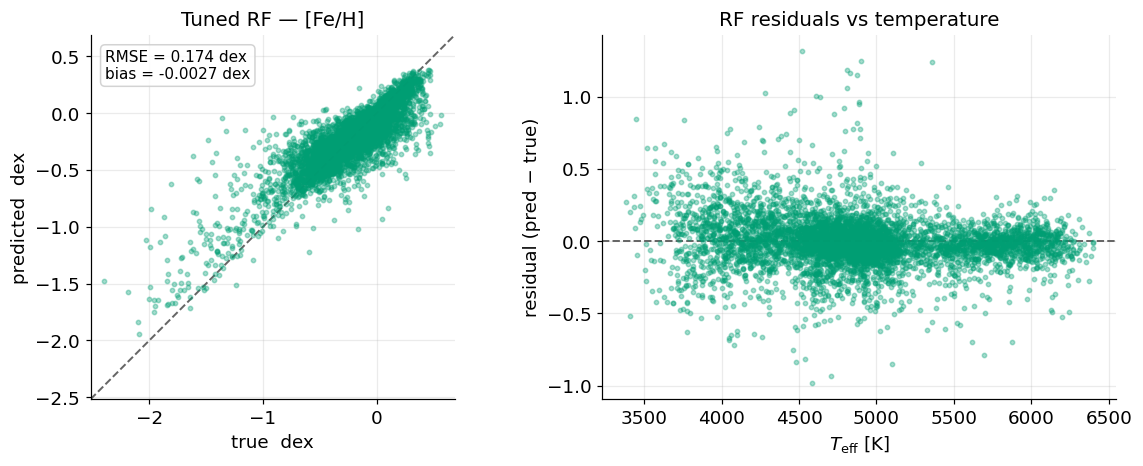

In [14]:
# Look, don't just summarize: predicted-vs-true and residuals vs temperature.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
plot_pred_vs_true(y_test, rf_test_pred, ax=axes[0],
                  color=COLORS["rf"], title="Tuned RF — [Fe/H]", units=" dex")
plot_residuals(y_test, rf_test_pred, feature=sp["y_test"]["Teff"],
               feature_name=r"$T_\mathrm{eff}$ [K]", ax=axes[1], color=COLORS["rf"])
axes[1].set_title("RF residuals vs temperature")
plt.tight_layout()
savefig("nb2b_rf_pred.png")
plt.show()

*Caption: points hug the 1:1 line more tightly than the linear baseline did. But the residual band still isn't a uniform stripe — its width changes across the data. A single RMSE can't see that; the next cells map *which stars* drive it.*

### 5.1 · The error map — *where* is the forest reliable?

A single RMSE hides *where* a model fails. The **Kiel diagram** (the `Teff`–`log g` plane astronomers
use — hot on the left, luminous giants at the top) lets us color each test star by its **absolute
error** and *see* the geography of trust.

But the Kiel plane only shows two axes. Your target, `[Fe/H]`, is a *third* — so we also bin the error
directly by `log g` and by `[Fe/H]`. **Let the numbers tell you where it breaks**, rather than
assuming.


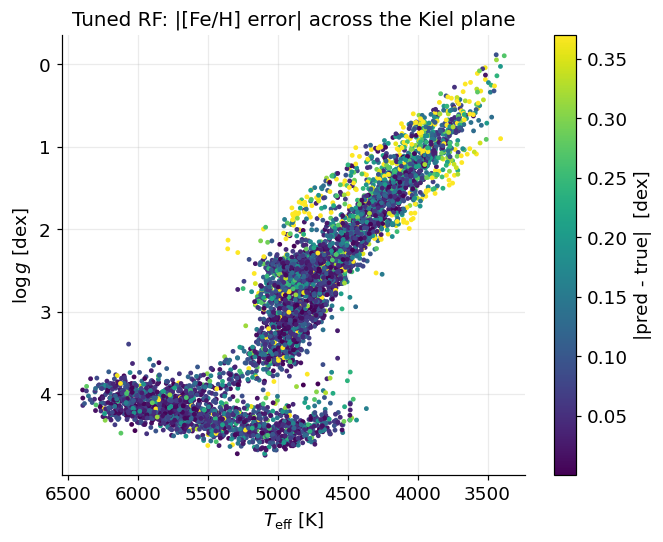

In [15]:
# Absolute [Fe/H] error per TEST star, placed on the Teff-logg plane (the Kiel diagram).
abs_err = np.abs(rf_test_pred - y_test)
teff = sp["y_test"]["Teff"].to_numpy()
logg = sp["y_test"]["logg"].to_numpy()
feh  = sp["y_test"]["FeH"].to_numpy()

fig, ax = plt.subplots(figsize=(6.8, 5.2))
sc = ax.scatter(teff, logg, c=abs_err, s=10, cmap="viridis",
                vmax=np.quantile(abs_err, 0.95))     # clip color so a few big errors don't wash it out
ax.invert_xaxis(); ax.invert_yaxis()                  # Kiel convention: hot left, giants top
ax.set_xlabel(r"$T_\mathrm{eff}$ [K]"); ax.set_ylabel(r"$\log g$ [dex]")
ax.set_title("Tuned RF: |[Fe/H] error| across the Kiel plane")
fig.colorbar(sc, label="|pred - true|  [dex]")
savefig("nb2b_rf_errormap.png")
plt.show()

# <- your turn: where are the errors largest? The luminous giants up top (low log g)?
#    The sparse metal-poor stars? Try coloring by SIGNED error (rf_test_pred - y_test)
#    instead -- is the forest biased high or low anywhere?

*Caption: the error is not uniform across the plane. Don't eyeball it alone — the next cell bins the error by `log g` **and** by `[Fe/H]` so you can read off exactly which stars are hard.*

In [16]:
# Quantify the discovery: mean |error| in terciles of log g and of [Fe/H].
def binned_error(values, name, n=3):
    edges = np.quantile(values, np.linspace(0, 1, n + 1)); edges[-1] += 1e-9
    print(f"mean |[Fe/H] error| by {name}:")
    for i in range(n):
        m = (values >= edges[i]) & (values < edges[i + 1])
        print(f"  {name} in [{edges[i]:7.2f}, {edges[i+1]:7.2f}] : "
              f"{abs_err[m].mean():.3f} dex   (n={m.sum()})")

binned_error(logg, "log g")    # low log g = luminous GIANTS; high log g = compact DWARFS
binned_error(feh,  "[Fe/H]")   # low [Fe/H] = METAL-POOR stars

mean |[Fe/H] error| by log g:
  log g in [  -0.12,    2.39] : 0.164 dex   (n=2000)
  log g in [   2.39,    3.47] : 0.095 dex   (n=2000)
  log g in [   3.47,    4.74] : 0.089 dex   (n=2000)
mean |[Fe/H] error| by [Fe/H]:
  [Fe/H] in [  -2.40,   -0.31] : 0.151 dex   (n=2000)
  [Fe/H] in [  -0.31,   -0.05] : 0.082 dex   (n=2000)
  [Fe/H] in [  -0.05,    0.57] : 0.114 dex   (n=2000)


*Caption: read these two tables together. The error is largest for the **lowest-`[Fe/H]`** stars (metal-poor — weak metal lines carry little information) and the **lowest-`log g`** stars (luminous giants — sparse and most-extrapolated). Metal-rich dwarfs are the easy case. That uneven, **conditional** error is exactly the problem next week's uncertainty work tackles.*

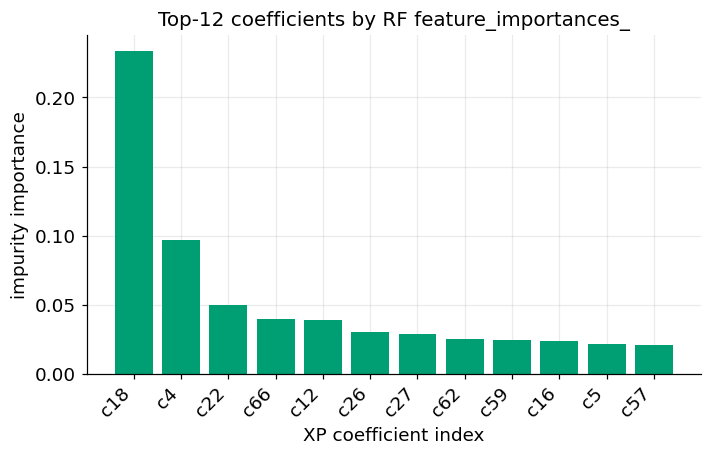

top-12 coefficient indices: [18, 4, 22, 66, 12, 26, 27, 62, 59, 16, 5, 57]


In [17]:
# Free goodie: which XP coefficients did the forest lean on? feature_importances_ is a 110-vector.
importances = rf_best.feature_importances_
order = np.argsort(importances)[::-1]
top = order[:12]

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(range(len(top)), importances[top], color=COLORS["rf"])
ax.set_xticks(range(len(top))); ax.set_xticklabels([f"c{j}" for j in top], rotation=45, ha="right")
ax.set_xlabel("XP coefficient index"); ax.set_ylabel("impurity importance")
ax.set_title("Top-12 coefficients by RF feature_importances_")
savefig("nb2b_rf_importances.png")
plt.show()

print("top-12 coefficient indices:", top.tolist())
# Heads-up: impurity importances are biased toward high-variance features and can mislead with
# correlated inputs. SHAP (section 6) is the more trustworthy attribution -- compare the two.

*Caption: a handful of the 110 coefficients carry most of the forest's `[Fe/H]` signal. Impurity importances are quick but can be biased (they favour high-cardinality / high-variance features) — §6's SHAP gives a more faithful picture, and it's instructive to compare which coefficients each method highlights.*

## 6 · Crack the forest open with SHAP (stretch)

A linear model lets you read its coefficients directly — "this coefficient pushes `[Fe/H]` up by *w*."
A forest of hundreds of trees has no such readout. **SHAP** (SHapley Additive exPlanations) fills the
gap: for *each* prediction it splits the model's output into per-feature contributions that **add up**
to that prediction, with fairness guarantees borrowed from game theory.

For tree models there's a shortcut: **`shap.TreeExplainer` is exact** (no sampling needed) and is fast
on *shallow* trees. One catch worth knowing: explaining a very **deep** forest (`max_depth=None`) is
slow — the cost grows with tree depth. So for this illustration we fit a lighter, **depth-limited**
forest; its feature ranking comes out essentially the same as your tuned model's. (KNN and neural nets
have no such shortcut — there SHAP must approximate on a small background set.)

Two views:

- **mean |SHAP|** per coefficient → a global importance bar (the trustworthy cousin of
  `feature_importances_`).
- **beeswarm** → every star is a dot, colored by the coefficient's value, so you see *direction* and
  *spread*, not just magnitude.

*Reference:* [SHAP documentation](https://shap.readthedocs.io/en/latest/) ·
[`TreeExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).


In [18]:
# SHAP on a random forest. shap.TreeExplainer is exact, but slow on DEEP trees — explaining your full
# max_depth=None forest takes minutes. So we fit a lighter, depth-limited forest on the tuning slice just
# for this picture (its feature ranking matches your tuned model's). This runs in ~2 s instead of ~3 min.
import shap

rf_light = make_model("rf", n_estimators=60, max_depth=10).fit(X_tune, y_tune)
scaler = rf_light.named_steps["standardscaler"]
forest = rf_light.named_steps["randomforestregressor"]

n_explain = 200                                   # explain a small sample of test stars
X_test_scaled = scaler.transform(sp["X_test"][:n_explain])

explainer = shap.TreeExplainer(forest)
shap_values = explainer.shap_values(X_test_scaled)   # shape (n_explain, 110)
print("computed SHAP values:", np.asarray(shap_values).shape)

mean_abs_shap = np.abs(shap_values).mean(axis=0)     # global importance per coefficient
shap_order = np.argsort(mean_abs_shap)[::-1]
print("top-8 coefficients by mean|SHAP|:", shap_order[:8].tolist())

computed SHAP values: (200, 110)
top-8 coefficients by mean|SHAP|: [18, 4, 66, 26, 24, 22, 12, 16]


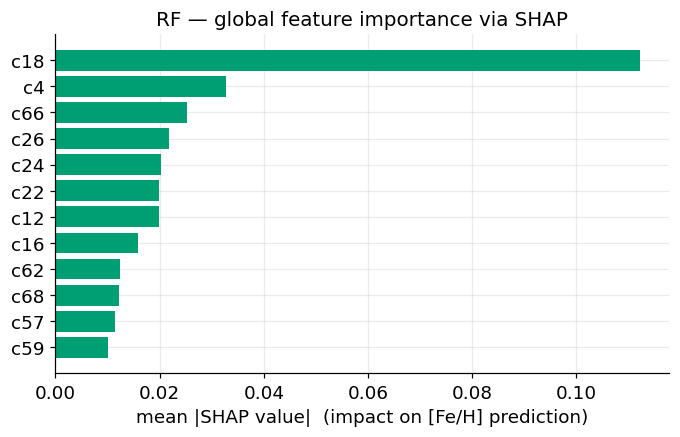

In [19]:
# View 1 -- global importance bar: mean|SHAP| for the top coefficients.
topk = shap_order[:12]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.barh(range(len(topk)), mean_abs_shap[topk][::-1], color=COLORS["rf"])
ax.set_yticks(range(len(topk)))
ax.set_yticklabels([f"c{j}" for j in topk[::-1]])
ax.set_xlabel("mean |SHAP value|  (impact on [Fe/H] prediction)")
ax.set_title("RF — global feature importance via SHAP")
savefig("nb2b_rf_shap_bar.png")
plt.show()

# <- your turn: compare these top coefficients to feature_importances_ from section 5.
#    Do the two methods agree on which coefficients matter most?

*Caption: the SHAP global-importance bar — the principled version of `feature_importances_`. A few coefficients dominate; compare the ranking to §5's impurity importances (they usually agree on the headline coefficients, disagree in the tail).*

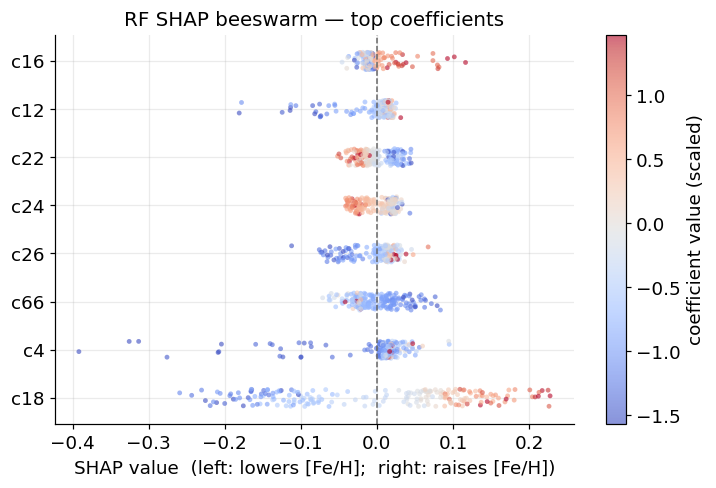

In [20]:
# View 2 -- beeswarm: every explained star is a dot. Hand-rolled (we don't import seaborn).
# For each top coefficient, plot its SHAP values with a little vertical jitter, colored by the
# (scaled) coefficient value -> you see DIRECTION (sign) and SPREAD, not just magnitude.
topk = shap_order[:8]
fig, ax = plt.subplots(figsize=(7.6, 4.6))
rng = np.random.default_rng(0)
for row, j in enumerate(topk):
    sv = shap_values[:, j]
    cval = X_test_scaled[:, j]
    jitter = rng.uniform(-0.18, 0.18, size=sv.shape[0])
    sc = ax.scatter(sv, row + jitter, c=cval, cmap="coolwarm", s=10, alpha=0.6,
                    vmin=np.quantile(cval, 0.02), vmax=np.quantile(cval, 0.98))
ax.axvline(0.0, color="0.4", lw=1.0, ls="--")
ax.set_yticks(range(len(topk))); ax.set_yticklabels([f"c{j}" for j in topk])
ax.set_xlabel("SHAP value  (left: lowers [Fe/H];  right: raises [Fe/H])")
ax.set_title("RF SHAP beeswarm — top coefficients")
cb = fig.colorbar(sc, ax=ax); cb.set_label("coefficient value (scaled)")
savefig("nb2b_rf_shap_beeswarm.png")
plt.show()

*Caption: each row is one coefficient; each dot one star. A dot's x-position is how much that coefficient pushed *that star's* `[Fe/H]` up (right) or down (left); its color is the coefficient's value. When color separates cleanly left-to-right, the coefficient has a consistent directional effect — the forest learned a monotone-ish response to it.*

## 7 · Save your work — model, predictions, and experiment log

Three artifacts travel forward, all via the project helpers:

1. **`save_model(best_pipe, "rf")`** → `models/rf.joblib`. A tuned model *is* an experiment result —
   persist the fitted pipeline so **Notebook 3 loads the exact forest you tuned** (no silent refit),
   and so you could reproduce this run weeks later.
2. **`save_outputs("rf_preds.npz", ...)`** → predictions and truths on **both** the calibration and
   test splits, in the fixed schema NB3/NB4 read. (Why calibration too? Next week you size and
   *guarantee* uncertainty intervals from the calibration residuals.)
3. **`outputs/rf_experiments.csv`** — the running log of every setting you tried. This is the
   bare-bones version of what tools like **MLflow** or **Weights & Biases** do for real teams: a
   durable, comparable record of "what did I try, and how did it score?"

The filename and keys are a fixed **contract** — don't rename them, or the later notebooks won't find
your work:

> `outputs/rf_preds.npz` with keys `y_cal_true, y_cal_pred, y_test_true, y_test_pred`.

The model string is **`"rf"`** (the neural net is `"nn"`, not `"mlp"`).


In [21]:
# 1) Save the fitted, tuned pipeline so NB3 can load the EXACT model you built.
path = save_model(best_pipe, "rf")
print("wrote", path)

# 2) Save predictions on BOTH the calibration and test splits (the NB2->NB3->NB4 contract).
save_outputs(
    "rf_preds.npz",
    y_cal_true =y_cal,
    y_cal_pred =best_pipe.predict(sp["X_cal"]),     # predictions on the held-out CALIBRATION split
    y_test_true=y_test,
    y_test_pred=best_pipe.predict(sp["X_test"]),    # predictions on the TEST split
)
print("wrote outputs/rf_preds.npz")

# Sanity check: reload and confirm the schema NB3/NB4 expect.
chk = load_outputs("rf_preds.npz")
print("keys:", sorted(chk.keys()), "| test preds shape:", chk["y_test_pred"].shape)

# 3) Look at your experiment log -- every run you tried, oldest to newest.
exp = pd.read_csv(os.path.join(OUTPUTS_DIR, "rf_experiments.csv"))
print(f"\nlogged {len(exp)} runs to outputs/rf_experiments.csv. Last few:")
print(exp.tail(6).to_string(index=False))

wrote /mnt/c/Users/joshs/Dropbox/GitHub/utssrp-2026/models/rf.joblib


wrote outputs/rf_preds.npz
keys: ['y_cal_pred', 'y_cal_true', 'y_test_pred', 'y_test_true'] | test preds shape: (6000,)

logged 123 runs to outputs/rf_experiments.csv. Last few:
 run  param_n_estimators  param_max_depth  param_min_samples_leaf param_max_features param_criterion  oob_r2  test_rmse  val_rmse  cv_rmse search final
 118                 NaN              NaN                     NaN               log2             NaN     NaN        NaN       NaN   0.2137    NaN   NaN
 119                 NaN              NaN                     NaN                NaN   squared_error     NaN        NaN       NaN   0.2057    NaN   NaN
 120                 NaN              NaN                     NaN                NaN    friedman_mse     NaN        NaN       NaN   0.2057    NaN   NaN
 121                 NaN              NaN                     1.0                1.0             NaN     NaN        NaN       NaN   0.2036   grid   NaN
 122                 NaN             24.0                     

*Caption: three artifacts written — `models/rf.joblib`, `outputs/rf_preds.npz`, and the growing `outputs/rf_experiments.csv`. Notebooks 3 and 4 load the saved model and predictions; the CSV is your lab notebook.*

## Wrap-up · What you tuned, and what's next

You ran a full tuning **lab** on the random forest: read the docstring, swept the continuous knobs by
hand and *saw* the bias–variance curve, compared the categorical menus, then let `GridSearchCV` and
`RandomizedSearchCV` search combinations for you — **logging every run** and **saving your best model**.
You scored it once on the untouched test set, mapped *where* it fails, and cracked it open with SHAP.

The two findings worth saying out loud at debrief:

- The tuned forest **beats the linear baseline** clearly (roughly 0.17 vs 0.22 dex) — but most of that
  win is RF being a better model *class*; hyperparameter tuning added only a sliver. "RF is robust to
  tuning" is itself a result.
- The errors **aren't uniform**. They pile up on **metal-poor stars and luminous giants** — the
  sparse, information-starved corners. A single RMSE can't express that uneven, *conditional* error.

That last point is the cliffhanger:

- **Notebook 3** turns your saved predictions into **uncertainty intervals** and asks whether they're
  *honest* — using the forest's *native* spread across trees — and finds the giants and metal-poor stars
  under-covered.
- **Notebook 4** makes the guarantee *rigorous* with **conformal prediction**, then shows exactly where
  the guarantee still strains.

Your `models/rf.joblib` and `outputs/rf_preds.npz` are the inputs to both. Bring your error map, your
SHAP bar, and a one-line "RF vs the baseline" verdict to the debrief.

### Further reading

- [RandomForestRegressor — API reference](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) — every knob: `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`, `criterion`, `oob_score`, `feature_importances_`.
- [Ensemble methods — forests of randomized trees (User Guide)](https://scikit-learn.org/stable/modules/ensemble.html#forest) — why bagging + feature randomness works, and the bias–variance intuition.
- [Tuning hyper-parameters — `GridSearchCV` & `RandomizedSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html) — exhaustive vs randomized search, scoring strings, and the `step__param` naming.
- [SHAP documentation](https://shap.readthedocs.io/en/latest/) and [`shap.TreeExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html) — fast, exact attributions for tree models; the beeswarm and bar summaries.
- *What real teams use to track experiments:* [MLflow Tracking](https://mlflow.org/docs/latest/tracking.html) and [Weights & Biases](https://docs.wandb.ai/) — the production-grade version of our `log_experiment` CSV.
- Laroche & Speagle 2025, *"Closing the Stellar Labels Gap"* — the science this lab is built on: [arXiv:2404.07316](https://arxiv.org/abs/2404.07316).
